In [48]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib

In [49]:
# Read in the data.

# Save the figures?
save_the_fig = True

# Do for the short test or the long test??
short = True

if short:
    fv3_case = 'cam_6_4_095_paper_nine_fv3_C96_small_dt'
    fv3_run_base = "/glade/derecho/scratch/timand/"
    fv3_nc_file = fv3_case + '.cam.h0i.0001-01-01-00000_acid_L58.regrid.1x1.nc'

    se_case = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid_1min'
    se_run_base = '/glade/derecho/scratch/nforcone/'
    se_nc_file = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid_1min.cam.h0i.0001-01-01-00000.nc'
else:
    fv3_case = 'cam_6_4_095_paper_nine_fv3_C96'
    fv3_run_base = "/glade/derecho/scratch/timand/"
    fv3_nc_file = 'cam_6_4_095_paper_nine_fv3_C96.cam.h0i.0001-01-01-00000_acid_L58_one_day.regrid.1x1.nc'

    se_case = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid'
    se_run_base = '/glade/derecho/scratch/nforcone/'
    se_nc_file = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid.cam.h0i.0001-01-01-00000.nc'

    eul_case = 'cesm2.1.5_03052026.EULT85.L58.fadiab.acid'
    eul_run_base = '/glade/derecho/scratch/cjablono/'    
    eul_nc_file = 'cesm2.1.5_03052026.EULT85.L58.fadiab.acid.cam.h0.0001-01-01-00000.PS.U850.OMEGA850.OMEGA500.U.Z3.PHIS.1_day.regrid.1x1.nc'
    

#run_base = "/glade/derecho/scratch/timand/"
fv3_run_path = fv3_run_base + fv3_case + '/run/' + fv3_nc_file
se_run_path = se_run_base + se_case + '/run/' + se_nc_file

nc_fv3 = Dataset(fv3_run_path, 'r')
nc_se = Dataset(se_run_path, 'r')

if not short:
    eul_run_path = eul_run_base + eul_case + '/run/' + eul_nc_file
    nc_eul = Dataset(eul_run_path, 'r')
    

In [50]:
time = nc_fv3['time'][:]
lat_deg = nc_fv3['lat'][:] 
lon_deg = nc_fv3['lon'][:] 

lat = lat_deg*np.pi/180
lon = lon_deg*np.pi/180

print(np.min(lon))
print(np.max(lon))
print(np.min(lat))
print(np.max(lat))

0.0
6.265732014659642
-1.5707963267948966
1.5707963267948966


In [51]:
field_name = 'OMEGA850'
field_fv3 = nc_fv3[field_name][:]
field_se = nc_se[field_name][:]

if not short:
    field_eul = nc_eul[field_name][:]

print(np.shape(field_fv3))

(31, 181, 360)


In [52]:
# Extract the indices that are not over the mountain
def great_arc_dist(lon, lat, lon_c, lat_c):
    return np.acos(np.sin(lat_c)*np.sin(lat) + np.cos(lat_c)*np.cos(lat)*np.cos(lon-lon_c))

In [53]:
lat_c = 0
lon_c = 3*np.pi/2
Rm = 6*np.pi/180

count=0

r_vals = np.zeros((len(lon), len(lat)))
for i in np.arange(len(lon)):
    for j in np.arange(len(lat)):
        r_vals[i,j] = great_arc_dist(lon[i], lat[j], lat_c, lon_c)
        if r_vals[i,j] < Rm:
            field_fv3[:, j, i] = 0
            field_se[:, j, i] = 0
            if not short:
                field_eul[:, j, i] = 0
            count += 1

print(np.min(r_vals))
print(np.max(r_vals))

print(f'Number of removed (mountain) values is {count}')

0.0
3.141592653589793
Number of removed (mountain) values is 2160


In [54]:
# Compute maxs at each time
field_fv3_maxs = np.max(field_fv3, axis=(1,2))
field_se_maxs = np.max(field_se, axis=(1,2))

if not short:
    field_eul_maxs = np.max(field_eul, axis=(1,2))

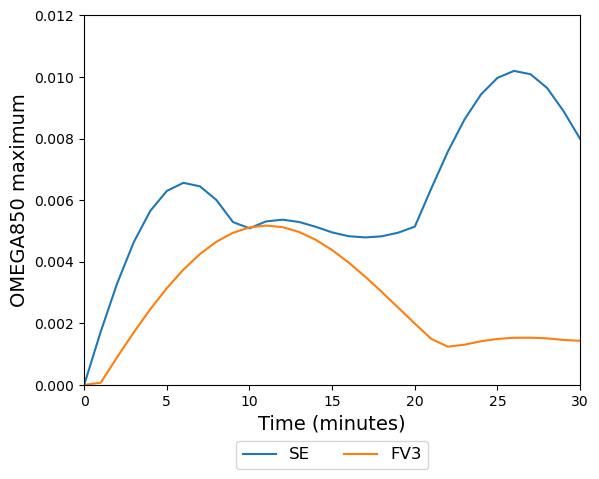

In [58]:
time_mins = time*24*60
end_idx = len(time)

if short:
    plt.figure()
    plt.plot(time_mins, field_se_maxs[0:end_idx], label='SE')
    plt.plot(time_mins, field_fv3_maxs, label='FV3')
    plt.xlim([time_mins[0],time_mins[-1]])
    plt.ylim([0,0.012])
    plt.ylabel(f'{field_name} maximum', size=14)
    plt.xlabel('Time (minutes)', size=14)
    plt.legend(loc='lower center', prop={'size': 12}, bbox_to_anchor=(0.5, -0.25), ncol=2)
    #plt.title(f'Acid test, L58, Maximum in the {field_name} field')
    if save_the_fig:
        plt.savefig('figures/acid_OMEGA850_short', bbox_inches='tight')
else:
    plt.figure()
    plt.plot(time_mins, field_se_maxs[0:end_idx], label='SE')
    plt.plot(time_mins, field_fv3_maxs, label='FV3')
    plt.plot(time_mins, field_eul_maxs, label='EUL')
    plt.xlim([time_mins[0],time_mins[-1]])
    plt.ylim([0,0.015]) 
    plt.ylabel(f'{field_name} maximum',size=14)
    plt.xlabel('Time (minutes)',size=14)
    #plt.title(f'Acid test, L58, Maximum in the {field_name} field')
    plt.legend(loc='lower center', prop={'size': 12}, bbox_to_anchor=(0.5, -0.25), ncol=3)
    if save_the_fig:
        plt.savefig('figures/acid_OMEGA850_one_day', bbox_inches='tight')

